# GYM - ÁRBOLES DE DECISIÓN

- Ahora para predecir la satisfacción

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
## Cargamos los datos

data = pd.read_excel(r"dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")

data.head()

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


# PRIMER ARBOL - DECISION TREE CLASIFFIER

In [3]:
#Definicion del modelo

x = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
# Entrenamiento del modelo (Aquí se puede cambiar el modelo a RandomForestClassifier si se desea)

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [6]:
# Evaluar el modelo

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Árbol de Decisión — Métricas de evaluación")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_tree, target_names=["No Satisfecho", "Satisfecho"]))

Árbol de Decisión — Métricas de evaluación
Accuracy: 0.9

Matriz de confusión:
[[28  3]
 [ 3 26]]

Reporte de clasificación:
               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



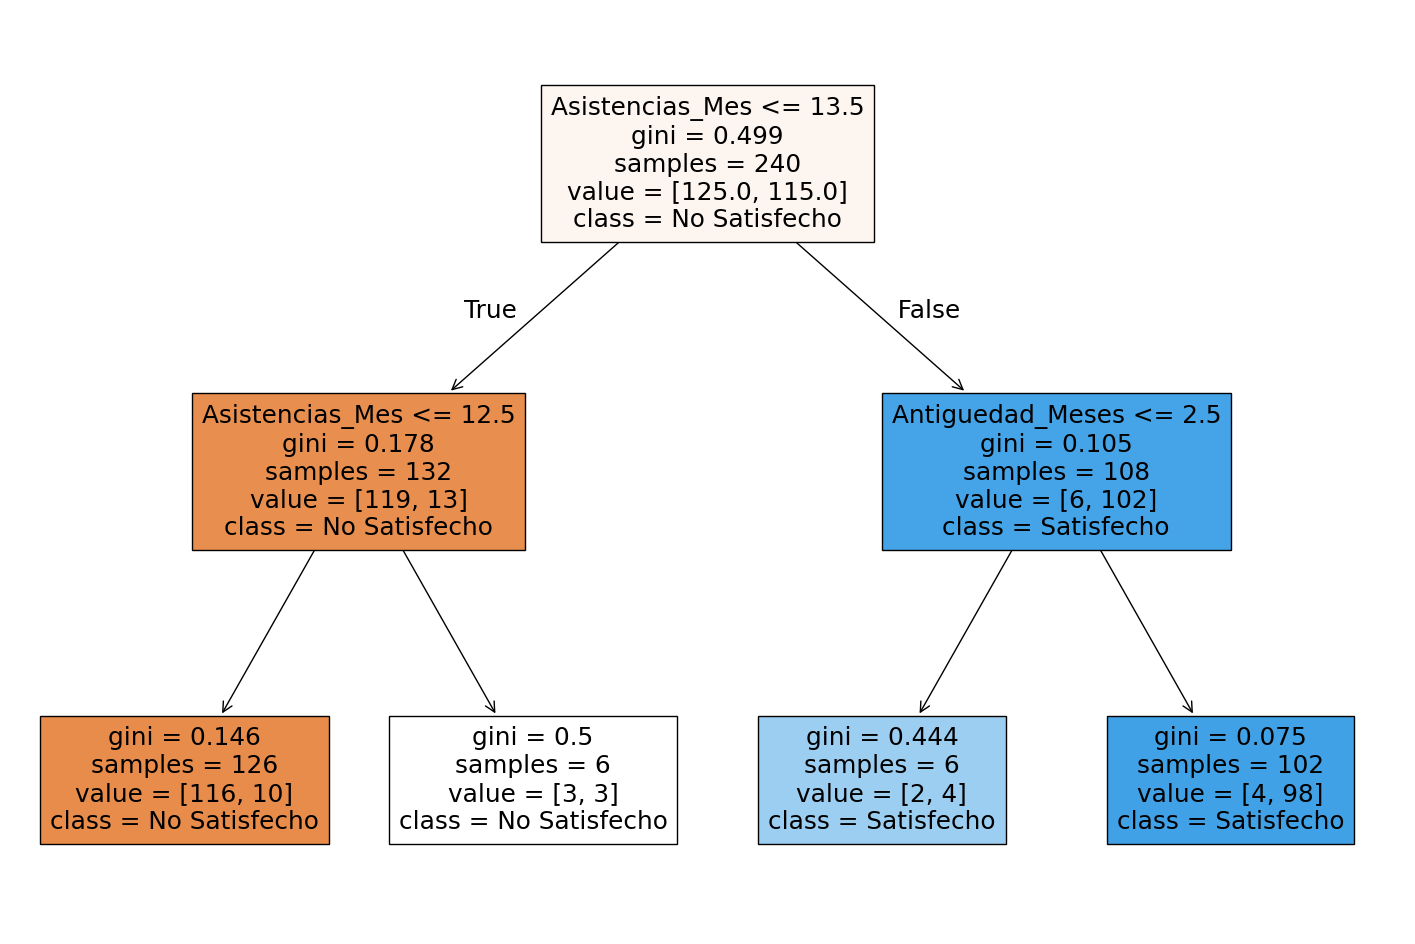

In [7]:
#Visualizar el árbol de decisión


plt.figure(figsize=(18, 12))

plot_tree(
    tree,
    feature_names=x.columns,
    class_names=["No Satisfecho", "Satisfecho"],
    filled=True
)


plt.show()

# Conclusión
- Los que más asisten al gym están más satisfechos: 
- Si vienes más de 13 veces al mes & llevan más de 2.5 meses tienen una alta probabilidad de estar satisfechos. 


##### Rama derecha: de los 108 clientes: 102 satisfechos | 6 no satisfechos
##### Segunda rama derecha: ¿Lleva menos de 2.5 meses?
- SÍ --> 6 Clientes: 4 satisfechos y 2 no satisfechos
- NO --> 102 Clientes: 98 Satisfechos y 4 no satisfechos

##### Rama izquierda: de los 132 que llegan, 119 no satisfechos y 13 si lo estan. 

##### Segunda rama izquierda: ¿Cuánto viene este cliente?
- NO --> 116 no satisfechos y 10 satisfechos
- SI --> empate 3 no satisfechos y 3 satisfechos

- Gini = 0.499  → value [125, 115] → casi empate
- Gini = 0.178  → value [119, 13]  → casi todo No Satisfecho
- Gini = 0.105  → value [6, 102]   → casi todo Satisfecho

In [ ]:
# Importancia o contribución de cada variable individual al modelo

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
}).sort_values(by="importance", ascending=False)
print(importances)

               feature  importance
1      Asistencias_Mes    0.988862
0     Antiguedad_Meses    0.011138
2       Horas_Pico_Mes    0.000000
3  Gasto_Mensual_Extra    0.000000


In [9]:
from sklearn.tree import export_text

rules = export_text(tree, feature_names=list(x.columns))
print(rules)

|--- Asistencias_Mes <= 13.50
|   |--- Asistencias_Mes <= 12.50
|   |   |--- class: 0
|   |--- Asistencias_Mes >  12.50
|   |   |--- class: 0
|--- Asistencias_Mes >  13.50
|   |--- Antiguedad_Meses <= 2.50
|   |   |--- class: 1
|   |--- Antiguedad_Meses >  2.50
|   |   |--- class: 1



# Random Forest - Gym

In [10]:
# Construir el modelo random forest 

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred_rf = rf.predict(X_test)

In [12]:
print("RANDOM FOREST - Métricas de evaluación")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["No satisfecho", "Satisfecho"]))

RANDOM FOREST - Métricas de evaluación
Accuracy: 0.9
Matriz de confusión:
[[28  3]
 [ 3 26]]
               precision    recall  f1-score   support

No satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



# XGBOOST - Gym

In [13]:
from xgboost import XGBClassifier, plot_importance, plot_tree, to_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [14]:
# ============================================================
# 1. DEFINICIÓN DEL MODELO
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [15]:
# ============================================================
# 2. ENTRENAMIENTO
# ============================================================
xgb_model.fit(X_train, y_train)

# ============================================================
# 3. PREDICCIÓN Y MÉTRICAS
# ============================================================
y_pred = xgb_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8833333333333333

Matriz de confusión:
[[28  3]
 [ 4 25]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        31
           1       0.89      0.86      0.88        29

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



<Figure size 1000x600 with 0 Axes>

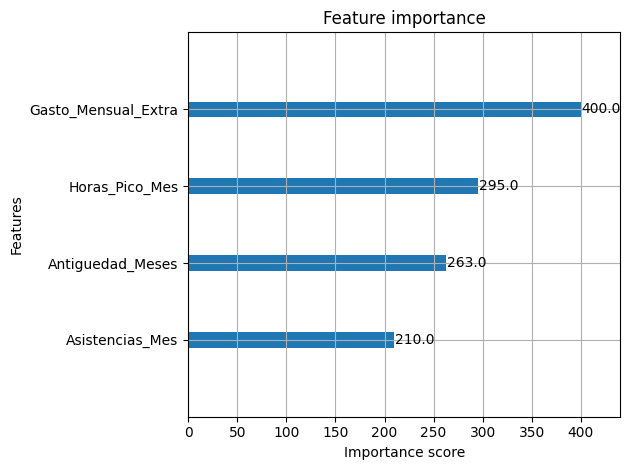

In [17]:
# ============================================================
# 4. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================
plt.figure(figsize=(10, 6))
plot_importance(xgb_model)
plt.tight_layout()  # ← evita que las etiquetas se corten
plt.show()

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 5000x3000 with 0 Axes>

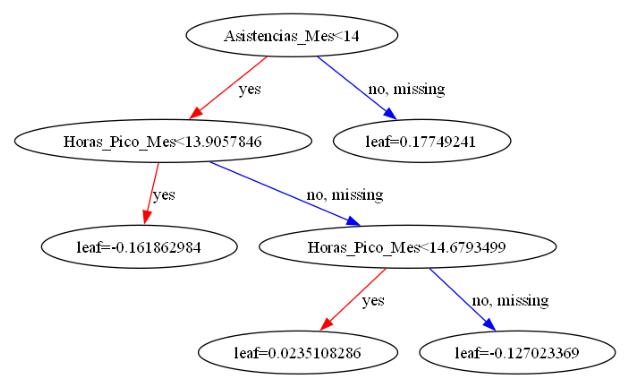

In [18]:
# ============================================================
# 5. VISUALIZACIÓN DE UN ÁRBOL (árbol nº 0)
# ============================================================
plt.figure(figsize=(50, 30))
plot_tree(xgb_model, num_trees=0)
plt.tight_layout()
plt.show()

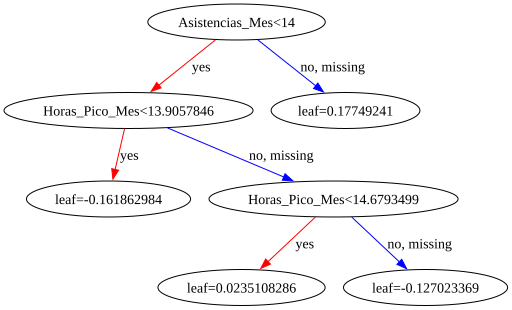

In [19]:
from xgboost import to_graphviz

graph = to_graphviz(xgb_model, num_trees=0)
graph  # ← esta línea es obligatoria en Jupyter para que se renderice